Setup and Clone

In [1]:
!git clone https://github.com/ayiii-a/Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual.git
from google.colab import drive
drive.mount('/content/drive')

import os
%cd Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual

Cloning into 'Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 29 (delta 5), reused 16 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 5.15 MiB | 15.42 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Mounted at /content/drive
/content/Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual


Data Loading and Distribution Visualization

start loading TweepFake data...
Train size: 20712 | Test size: 2558


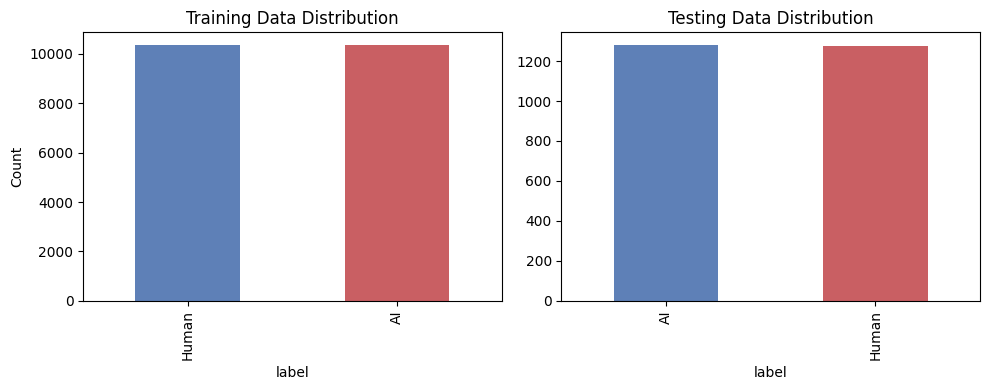

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load TweepFake data (use ';' separator)
print("start loading TweepFake data...")
train_df = pd.read_csv("./data/train.csv", sep=';')
test_df = pd.read_csv("./data/test.csv", sep=';')

train_df.rename(columns={'text': 'Text'}, inplace=True)
test_df.rename(columns={'text': 'Text'}, inplace=True)

# map labels (Human=0, Bot=1)
label_map = {"human": 0, "bot": 1}
train_df['label'] = train_df['account.type'].str.lower().map(label_map)
test_df['label'] = test_df['account.type'].str.lower().map(label_map)

# clean missing values
train_df = train_df[['Text', 'label']].dropna()
test_df = test_df[['Text', 'label']].dropna()

# extract arrays
X_train, y_train = train_df['Text'].values, train_df['label'].values
X_test, y_test = test_df['Text'].values, test_df['label'].values

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# VISUALIZATION 1: Data Distribution

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# train plot
train_counts = train_df['label'].value_counts().rename(index={0: 'Human', 1: 'AI'})
train_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52'], alpha=0.9)
axes[0].set_title('Training Data Distribution')
axes[0].set_ylabel('Count')

# test plot
test_counts = test_df['label'].value_counts().rename(index={0: 'Human', 1: 'AI'})
test_counts.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#C44E52'], alpha=0.9)
axes[1].set_title('Testing Data Distribution')

plt.tight_layout()
plt.show()

Tokenizer and DataLoader

In [3]:
import torch
from transformers import AutoTokenizer
from torch.utils.data import DataLoader, TensorDataset

# tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
vocab_size = tokenizer.vocab_size

def preprocess_for_lstm(texts, tokenizer, max_len=128):
    encoded = tokenizer(
        texts.tolist(), padding='max_length', truncation=True,
        max_length=max_len, return_tensors='pt'
    )
    return encoded['input_ids']

# dataLoaders
print("start tokenizing training data...")
X_train_tensor = preprocess_for_lstm(X_train, tokenizer)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)

print("start tokenizing testing data...")
X_test_tensor = preprocess_for_lstm(X_test, tokenizer)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
eval_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

print("DataLoaders ready...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

start tokenizing training data...
start tokenizing testing data...
DataLoaders ready...


LSTM Training

In [4]:
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size=100, hidden_size=128):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        embeds = self.embedding(x)
        _, (h_n, _) = self.lstm(embeds)
        logits = self.fc(h_n.squeeze(0))
        return logits

# training setup
device = "cuda" if torch.cuda.is_available() else "cpu"
model = LSTMClassifier(vocab_size=vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# training loop
epochs = 5
print(f"start training LSTM on {device.upper()} ...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")
print("LSTM training complete!")

start training LSTM on CUDA ...
Epoch [1/5], Loss: 0.6943
Epoch [2/5], Loss: 0.6931
Epoch [3/5], Loss: 0.6935
Epoch [4/5], Loss: 0.6935
Epoch [5/5], Loss: 0.6567
LSTM training complete!


Evaluation

start evaluation on test set...

-------------------------------------------------------
STRATEGY A: HIGH PRECISION (Threshold 0.5)
Goal: minimal false bans of human accounts
-------------------------------------------------------
AUC-ROC:   0.8624
F1-Score:  0.8202
Precision: 0.7677
Recall:    0.8805

Detailed Report:
              precision    recall  f1-score   support

   Human (0)       0.86      0.73      0.79      1278
      AI (1)       0.77      0.88      0.82      1280

    accuracy                           0.81      2558
   macro avg       0.81      0.81      0.81      2558
weighted avg       0.81      0.81      0.81      2558


-------------------------------------------------------
STRATEGY B: HIGH RECALL (Threshold 0.1)
Goal: catch maximum potential AI accounts
-------------------------------------------------------
AUC-ROC:   0.8624
F1-Score:  0.7570
Precision: 0.6131
Recall:    0.9891

Detailed Report:
              precision    recall  f1-score   support

   Human (0)

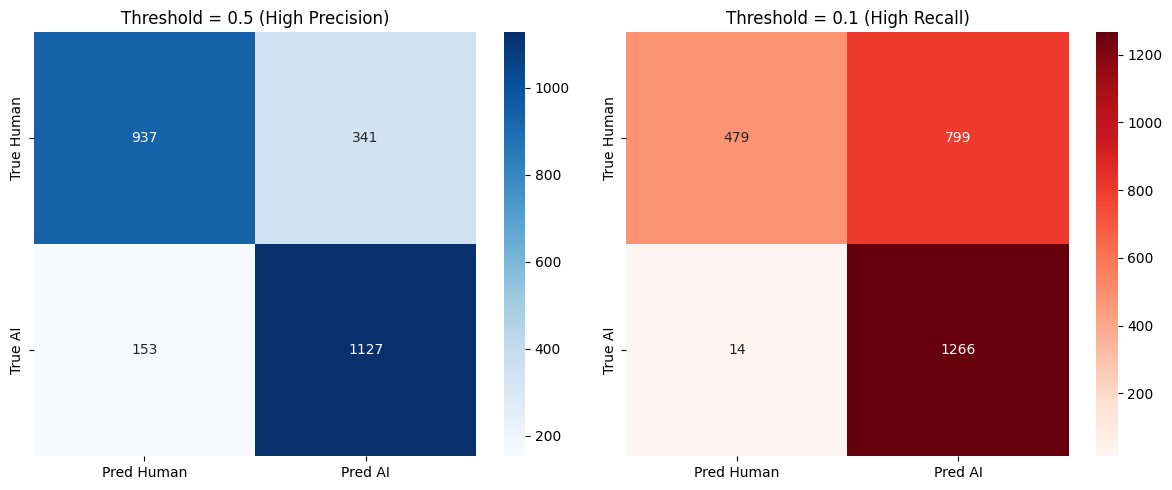

In [11]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, classification_report, confusion_matrix

model.eval()
all_probs = []

print("start evaluation on test set...")
with torch.no_grad():
    for texts, _ in eval_loader:
        texts = texts.to(device)
        outputs = model(texts)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())

all_probs = torch.tensor(all_probs)
y_test_tensor = y_test_tensor.cpu()

# AUC-ROC
global_auc = roc_auc_score(y_test_tensor, all_probs)

# EVALUATION A: High Precision (Threshold 0.5)
thresh_A = 0.5
preds_A = (all_probs > thresh_A).long()
cm_A = confusion_matrix(y_test_tensor, preds_A)

print("\n" + "-"*55)
print(f"STRATEGY A: HIGH PRECISION (Threshold {thresh_A})")
print("Goal: minimal false bans of human accounts")
print("-" * 55)
print(f"AUC-ROC:   {global_auc:.4f}")
print(f"F1-Score:  {f1_score(y_test_tensor, preds_A):.4f}")
print(f"Precision: {precision_score(y_test_tensor, preds_A):.4f}")
print(f"Recall:    {recall_score(y_test_tensor, preds_A):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test_tensor, preds_A, target_names=['Human (0)', 'AI (1)']))

# EVALUATION B: High Recall (Threshold 0.1)
thresh_B = 0.1
preds_B = (all_probs > thresh_B).long()
cm_B = confusion_matrix(y_test_tensor, preds_B)

print("\n" + "-"*55)
print(f"STRATEGY B: HIGH RECALL (Threshold {thresh_B})")
print("Goal: catch maximum potential AI accounts")
print("-" * 55)
print(f"AUC-ROC:   {global_auc:.4f}")
print(f"F1-Score:  {f1_score(y_test_tensor, preds_B):.4f}")
print(f"Precision: {precision_score(y_test_tensor, preds_B):.4f}")
print(f"Recall:    {recall_score(y_test_tensor, preds_B):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test_tensor, preds_B, target_names=['Human (0)', 'AI (1)']))

# VISUALIZATION: Confusion Matrix Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# plot Precision
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
axes[0].set_title(f'Threshold = {thresh_A} (High Precision)')

# lot Recall
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
axes[1].set_title(f'Threshold = {thresh_B} (High Recall)')

plt.tight_layout()
plt.show()